In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 20

DATA_DIR = Path("drawings")

SPIRAL_TRAIN = DATA_DIR/"spiral/training"
SPIRAL_TEST  = DATA_DIR/"spiral/testing"

WAVE_TRAIN = DATA_DIR/"wave/training"
WAVE_TEST  = DATA_DIR/"wave/testing"

OUTPUT_DIR = Path("outputs")
MODEL_DIR = OUTPUT_DIR/"models"
PLOT_DIR = OUTPUT_DIR/"plots"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
def load_data(train_path, test_path):

    train_gen = train_datagen.flow_from_directory(
        train_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    test_gen = test_datagen.flow_from_directory(
        test_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    return train_gen, test_gen

In [5]:
spiral_train, spiral_test = load_data(SPIRAL_TRAIN, SPIRAL_TEST)

Found 72 images belonging to 2 classes.
Found 30 images belonging to 2 classes.


In [6]:
def build_model():

    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name="auc")]
    )

    return model

In [7]:
model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,788 (16.70 MB)

 Trainable params: 328,705 (1.25 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [8]:
history = model.fit(
    spiral_train,
    validation_data=spiral_test,
    epochs=EPOCHS
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 987ms/step - accuracy: 0.4861 - auc: 0.4892 - loss: 0.7630 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6963
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 547ms/step - accuracy: 0.5000 - auc: 0.5559 - loss: 0.7304 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6934
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 687ms/step - accuracy: 0.5694 - auc: 0.5347 - loss: 0.8115 - val_accuracy: 0.5000 - val_auc: 0.5667 - val_loss: 0.6931
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 537ms/step - accuracy: 0.5694 - auc: 0.5367 - loss: 0.7825 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6933
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 635ms/step - accuracy: 0.5556 - auc: 0.5644 - loss: 0.7669 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7029
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 837ms/step - accuracy: 0.5417 - auc: 0.5231 - loss: 0.7515 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7178
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 585ms/step -

In [9]:
model.save(MODEL_DIR/"efficientnet_spiral.keras")

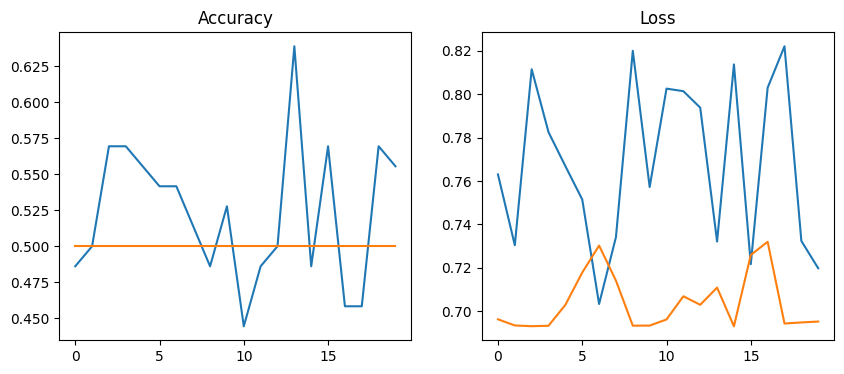

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")

plt.savefig(PLOT_DIR/"training_curve.png")
plt.show()

In [11]:
y_true = spiral_test.classes
y_pred_prob = model.predict(spiral_test)
y_pred = (y_pred_prob > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step 


In [12]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)

Accuracy: 0.5
Precision: 0.0
Recall: 0.0
F1: 0.0


e:\Projects\parkinson\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


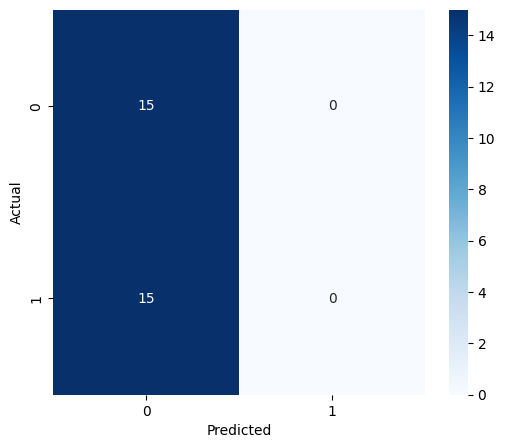

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(PLOT_DIR/"confusion_matrix.png")
plt.show()

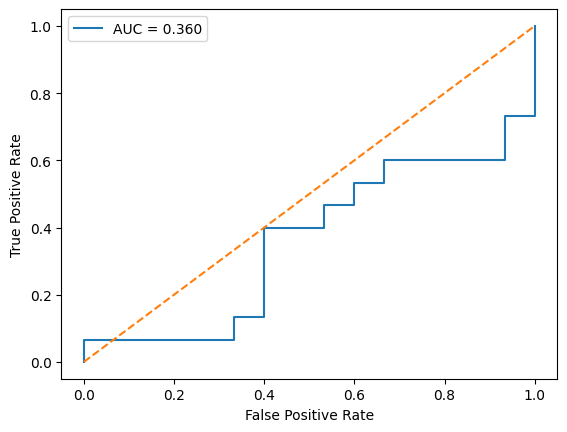

In [14]:
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig(PLOT_DIR/"roc_curve.png")
plt.show()

In [15]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap.numpy()

In [16]:
img_path = spiral_test.filepaths[0]

img = cv2.imread(img_path)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0

input_arr = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(input_arr, model, "top_conv")

heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = heatmap * 0.4 + img * 255

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(heatmap)
plt.title("Heatmap")

plt.subplot(1,3,3)
plt.imshow(overlay.astype("uint8"))
plt.title("GradCAM")

plt.savefig(PLOT_DIR/"gradcam.png")
plt.show()

e:\Projects\parkinson\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

In [17]:
def predict_image(image_path):

    img = cv2.imread(image_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img/255.0

    arr = np.expand_dims(img, axis=0)

    prob = model.predict(arr)[0][0]

    label = "Parkinson" if prob > 0.5 else "Healthy"

    print("Prediction:", label)
    print("PD Probability:", prob)

    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
    plt.show()

In [18]:
predict_image("drawings/spiral/testing/parkinson/sample.png")

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'
